# 04 — Timeline figures

Renders the poster-style PNGs into `figures/`. Four figures, one story:

| File | What it shows |
| --- | --- |
| `timeline_as_proposed.png` | every 8a+-and-up FA as a dot, milestones highlighted, grades as proposed at the FA |
| `timeline_as_consensus.png` | the same routes under today's grades — history rewritten |
| `timeline_conventions.png` | both milestone ladders on one axis, divergence made explicit |
| `timeline_with_disputed.png` | the proposed ladder with Akira and Chilam Balam admitted, so the reader can see what accepting the claims would do |

Colors are the repo's validated palette (blue = consensus, orange = proposed,
red = status-serious for disputed, always labeled, never color alone).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sportgradehistory import config
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal
from sportgradehistory.milestones import breakthrough_table, load_sport

sport = load_sport()
BASE = french_ordinal("8a+")
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
DOT = "#b8c4d4"   # the route cloud: recessive, one hue

tables = {c: breakthrough_table(sport, c) for c in ("as_proposed", "as_consensus")}
with_disputed = breakthrough_table(sport, "as_proposed", include_disputed=True)
config.FIGURES_DIR.mkdir(exist_ok=True)
rng = np.random.default_rng(7)

In [2]:
def timeline_poster(order_col, milestones, accent, title, subtitle, path,
                    disputed=None):
    hard = sport[(sport[order_col] >= BASE) & sport["first_ascent"].notna()]
    steps = hard[order_col] - BASE
    jitter = rng.uniform(-0.26, 0.26, len(hard))

    fig, ax = plt.subplots(figsize=(13.5, 7.6), dpi=150, facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    ax.plot(hard["first_ascent"], steps + jitter, "o", ms=3.4, mec="none",
            mfc=DOT, alpha=.55, zorder=1)

    ax.step(milestones["first_ascent"], milestones["grade_order"] - BASE,
            where="post", color=accent, lw=2, alpha=.5, zorder=2)
    ax.plot(milestones["first_ascent"], milestones["grade_order"] - BASE, "o",
            ms=9, mfc=accent, mec=SURFACE, mew=2, zorder=4)

    # Label placement, by rule rather than one fixed offset:
    #   * both lines always sit ABOVE the marker, so no label can fall onto the
    #     x axis (which is what the 8a+ and 8b labels used to do);
    #   * the side flips to the right when the previous milestone is close
    #     enough in time to collide (Liquid Ambar / Hubble, eleven weeks apart)
    #     or when the point is near the left edge, where a left-hand label
    #     would run off the axis and over the grade ticks;
    #   * a translucent halo keeps text legible over the route cloud.
    halo = dict(facecolor=SURFACE, edgecolor="none", alpha=.72,
                boxstyle="round,pad=0.14")
    left_edge = pd.Timestamp("1981-01-01")
    previous = None
    for _, m in milestones.iterrows():
        y = m["grade_order"] - BASE
        when = m["first_ascent"]
        crowded = previous is not None and (when - previous).days < 900
        near_edge = (when - left_edge).days < 950
        ha, dx = ("left", 11) if (crowded or near_edge) else ("right", -11)

        tie = " *" if pd.notna(m.get("ordering_unresolved_with")) else ""
        ax.annotate(f"{m['route']}  {when.year}{tie}", (when, y),
                    xytext=(dx, 21), textcoords="offset points", ha=ha,
                    fontsize=8.5, color=INK, fontweight="bold", zorder=5,
                    bbox=halo)
        ax.annotate(f"{m['climber']}", (when, y), xytext=(dx, 10),
                    textcoords="offset points", ha=ha, fontsize=7.5,
                    color=MUTED, zorder=5, bbox=halo)
        previous = when

    if disputed is not None and len(disputed):
        ax.plot(disputed["first_ascent"], disputed["grade_order"] - BASE, "o",
                ms=10, mfc="none", mec=RED, mew=2, zorder=6)
        for _, m in disputed.iterrows():
            # To the left: each claim's own row is empty on that side, where
            # the right-hand side runs straight into the milestone labels.
            ax.annotate(f"{m['route']}  {m['first_ascent'].year} — claimed, "
                        "not consensus",
                        (m["first_ascent"], m["grade_order"] - BASE),
                        xytext=(-14, -3), textcoords="offset points",
                        ha="right", fontsize=8, color=RED, zorder=7,
                        bbox=halo)

    ax.set_yticks(range(10))
    ax.set_yticklabels(FRENCH_SCALE[BASE:BASE + 10], fontsize=10, color=INK)
    ax.set_ylim(-0.8, 10.1)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlim(pd.Timestamp("1981-01-01"), pd.Timestamp("2028-06-01"))
    ax.grid(color=GRID, lw=.7, zorder=0)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
    for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED)
    ax.set_title(title, color=INK, fontsize=15, loc="left", pad=16,
                 fontweight="bold")
    ax.text(0, 1.015, subtitle, transform=ax.transAxes, fontsize=9,
            color=MUTED)
    ax.text(0.995, 0.015,
            "dot = one first ascent   * = same-year tie, ordering unresolved   "
            "data: climbing-history.org, 2026-09-09",
            transform=ax.transAxes, ha="right", fontsize=7.5, color=MUTED)
    plt.tight_layout()
    fig.savefig(path, facecolor=SURFACE, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"wrote {path.name}")

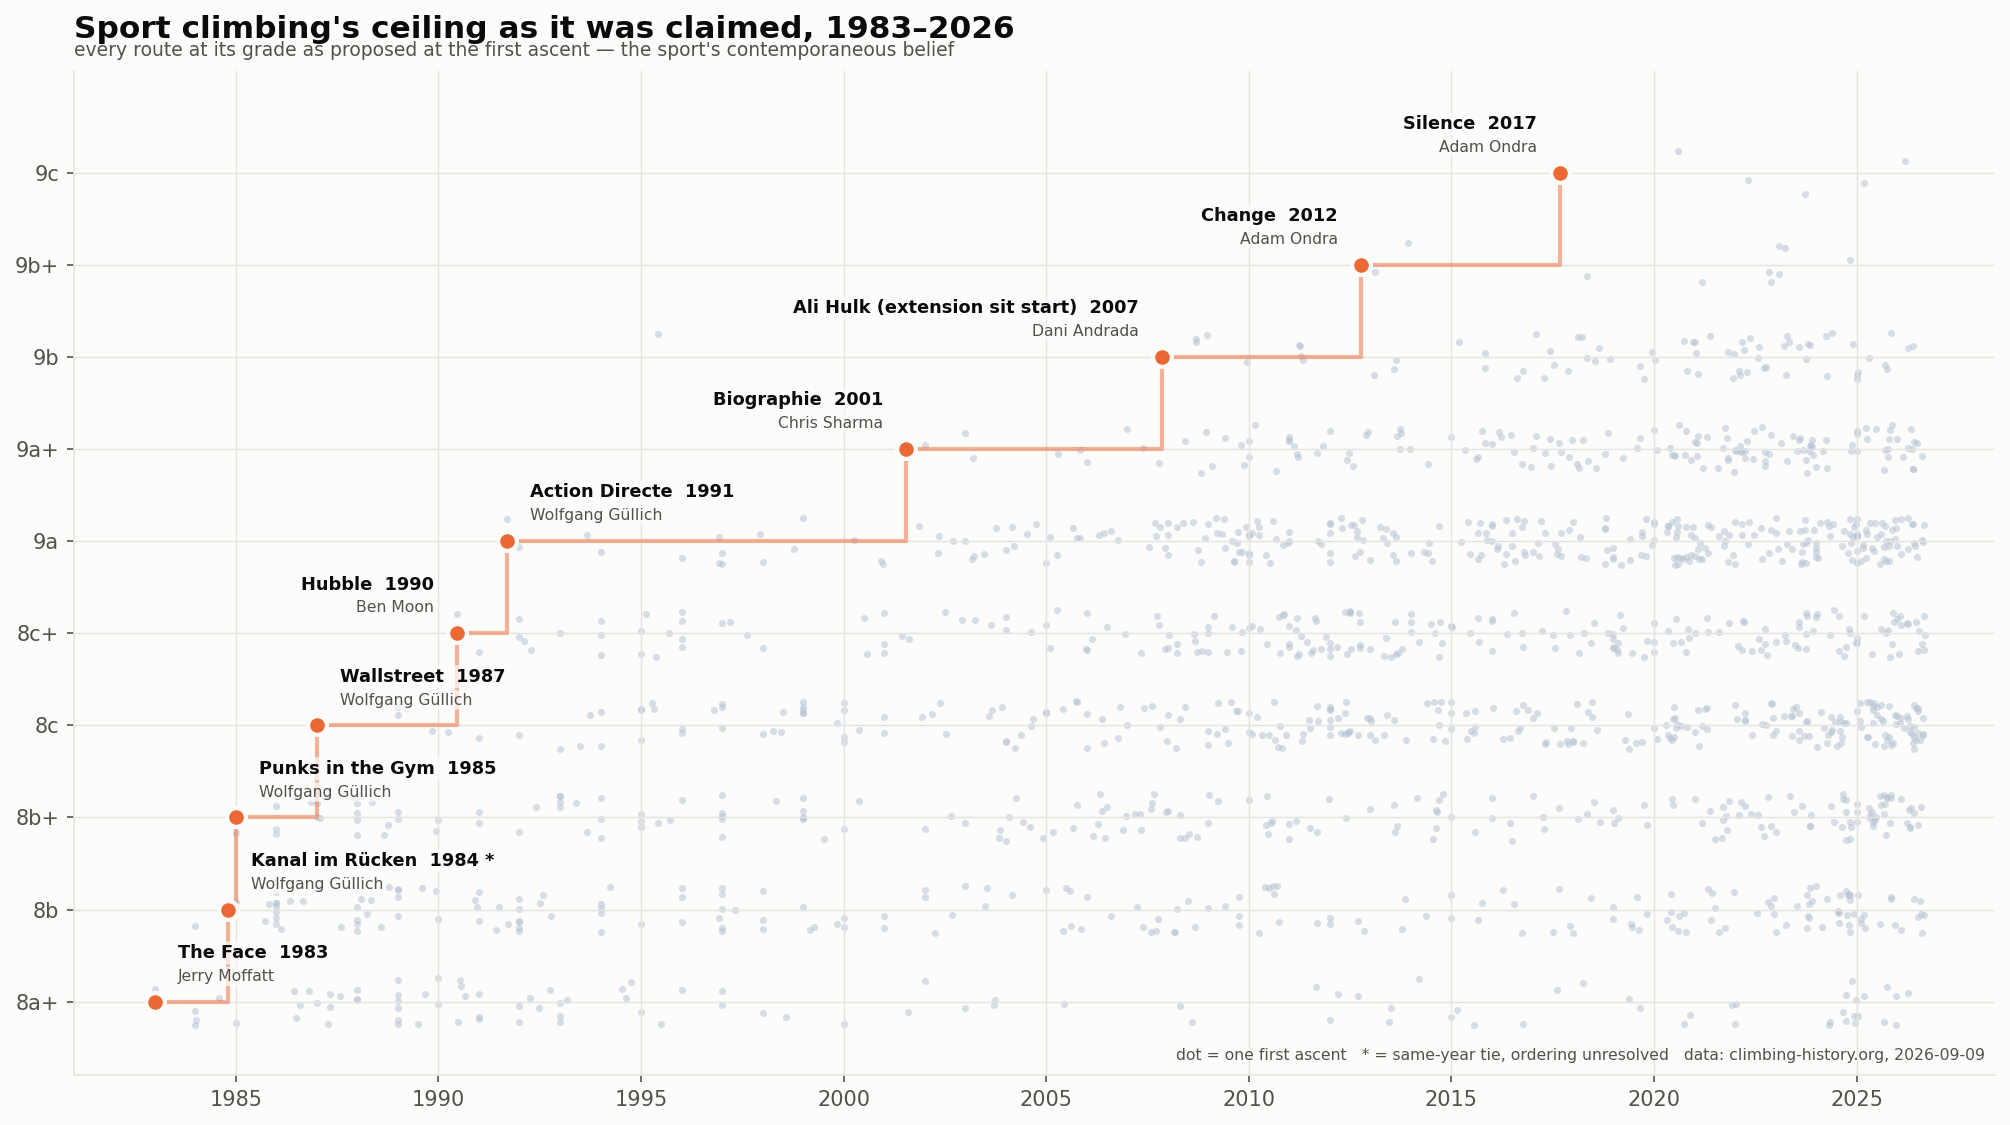

wrote timeline_as_proposed.png


In [3]:
timeline_poster(
    "proposed_order", tables["as_proposed"], ORANGE,
    "Sport climbing's ceiling as it was claimed, 1983–2026",
    "every route at its grade as proposed at the first ascent — the sport's "
    "contemporaneous belief",
    config.FIGURES_DIR / "timeline_as_proposed.png")

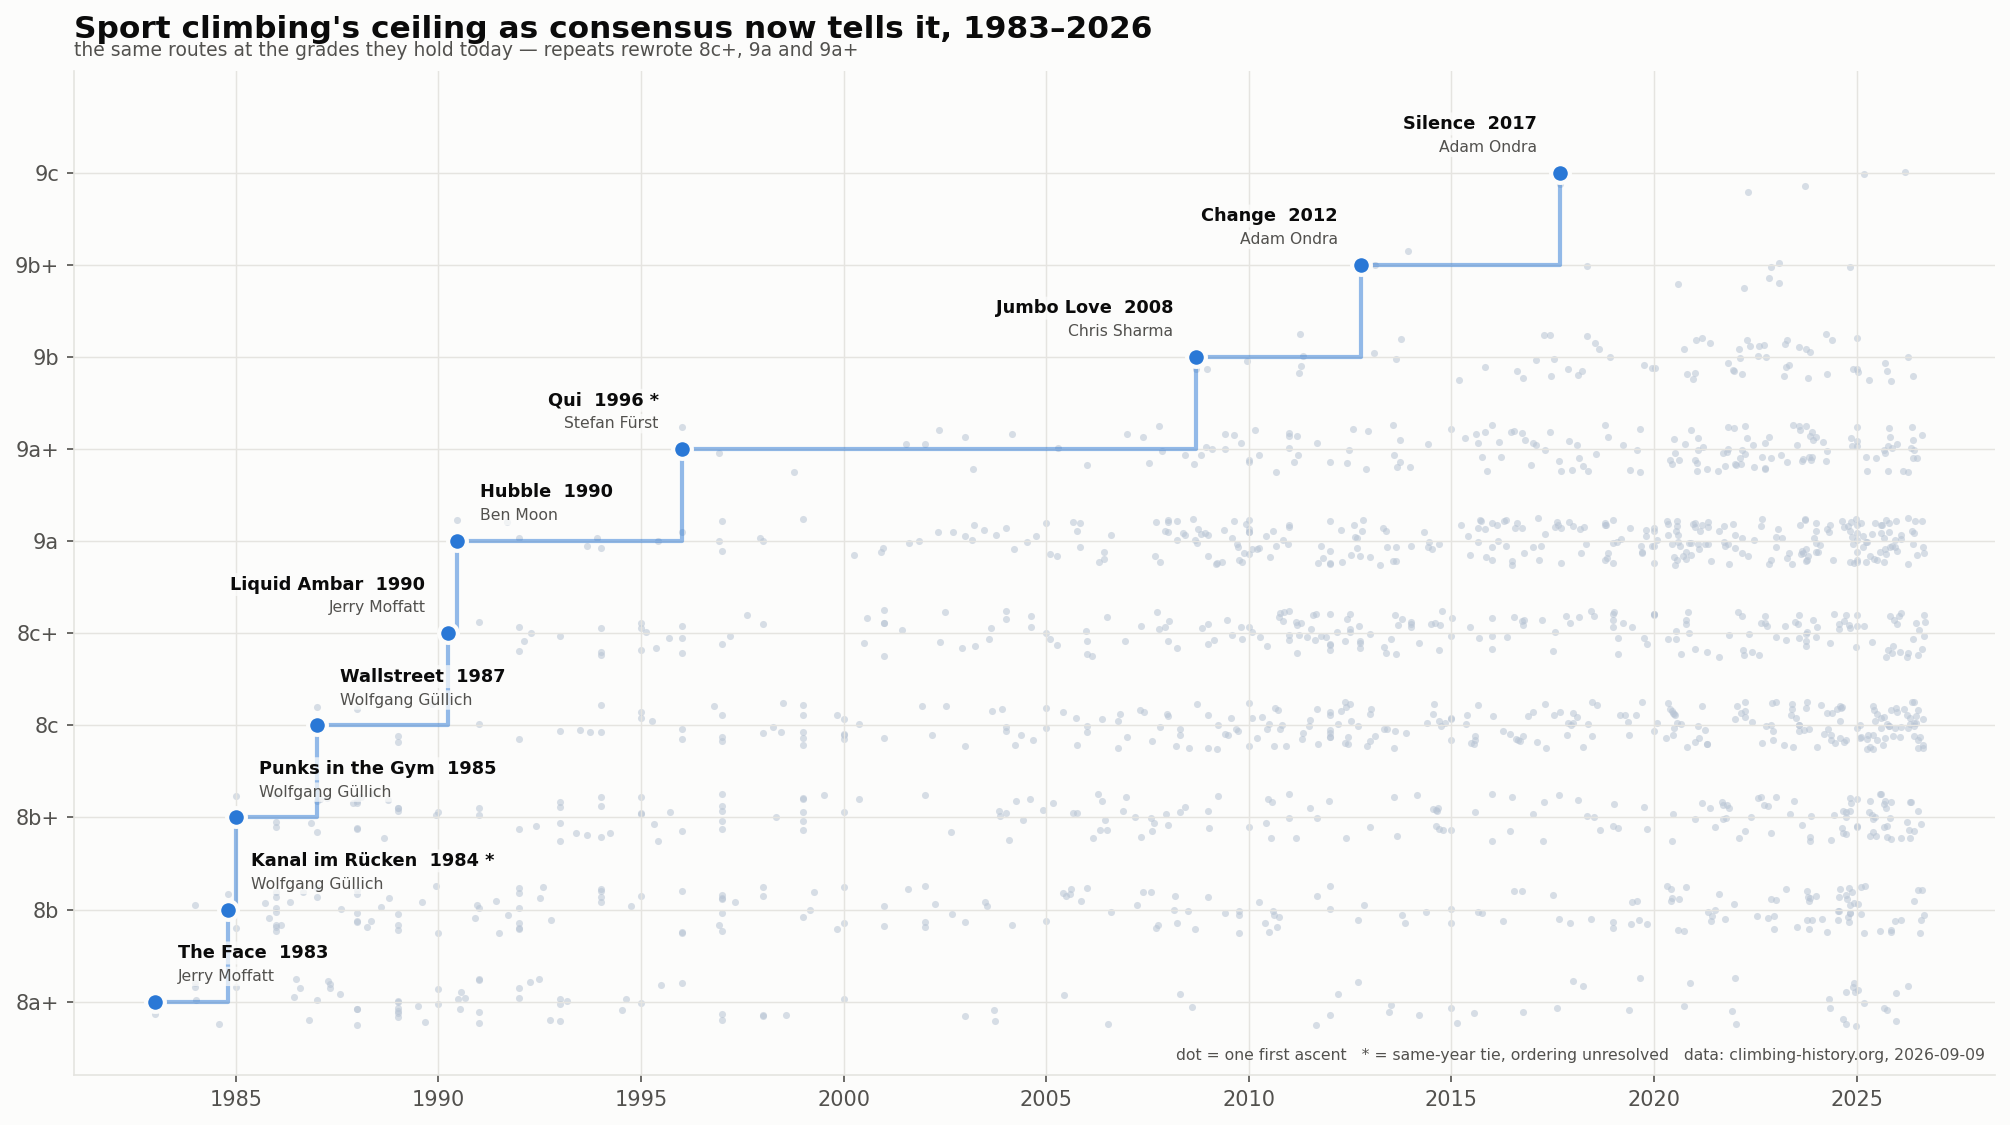

wrote timeline_as_consensus.png


In [4]:
timeline_poster(
    "grade_order", tables["as_consensus"], BLUE,
    "Sport climbing's ceiling as consensus now tells it, 1983–2026",
    "the same routes at the grades they hold today — repeats rewrote 8c+, 9a "
    "and 9a+",
    config.FIGURES_DIR / "timeline_as_consensus.png")

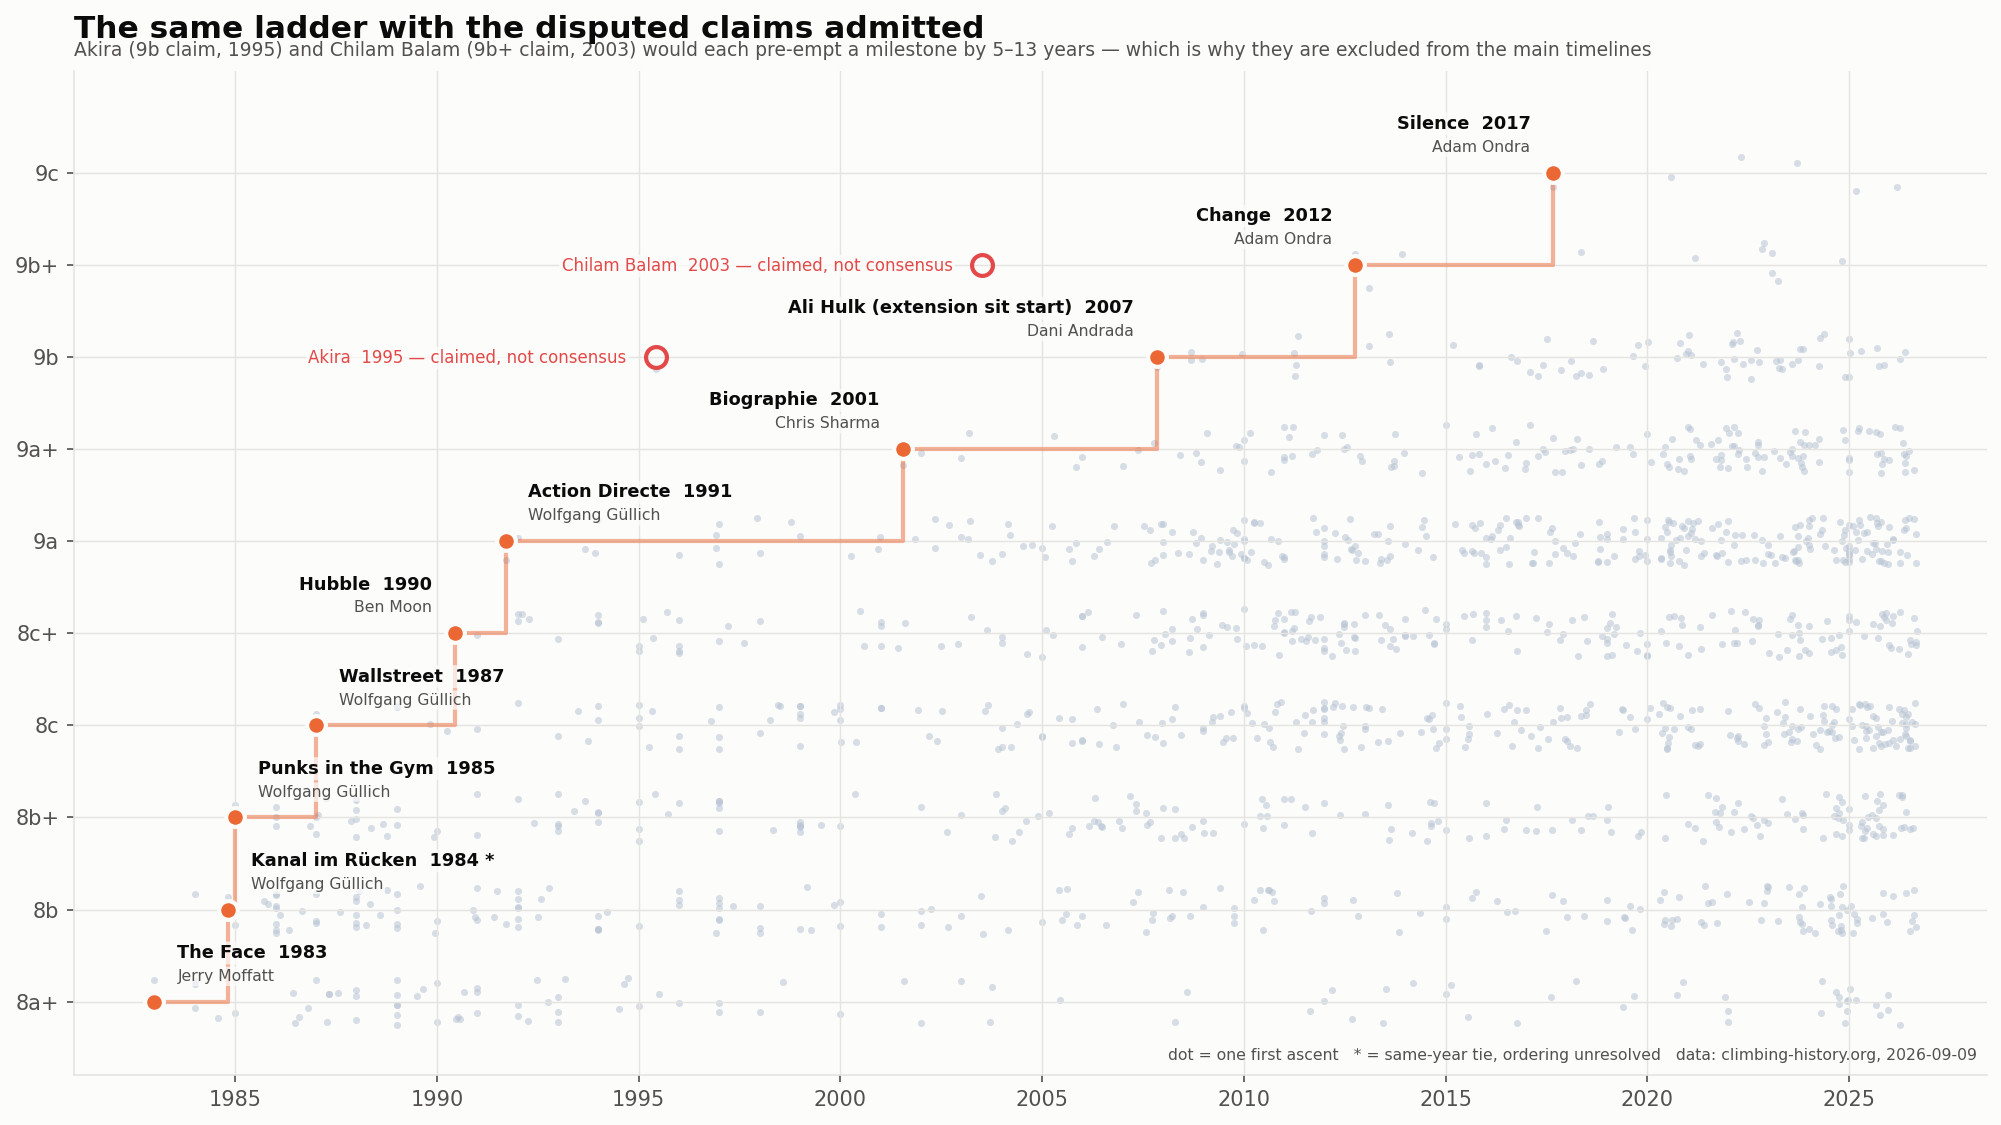

wrote timeline_with_disputed.png


In [5]:
# Each claim is drawn once, at the grade it claimed. The breakthrough pass also
# carries Akira down to 9a+ (a 1995 "9b" is at or above 9a+ before Biographie),
# but nobody claimed Akira at 9a+, so that row is not a claim to show.
disp = with_disputed[(with_disputed["status"] == "disputed")
                     & (with_disputed["grade"] == with_disputed["grade_at_fa"])]
timeline_poster(
    "proposed_order", tables["as_proposed"], ORANGE,
    "The same ladder with the disputed claims admitted",
    "Akira (9b claim, 1995) and Chilam Balam (9b+ claim, 2003) would each "
    "pre-empt a milestone by 5–13 years — which is why they are excluded "
    "from the main timelines",
    config.FIGURES_DIR / "timeline_with_disputed.png",
    disputed=disp)

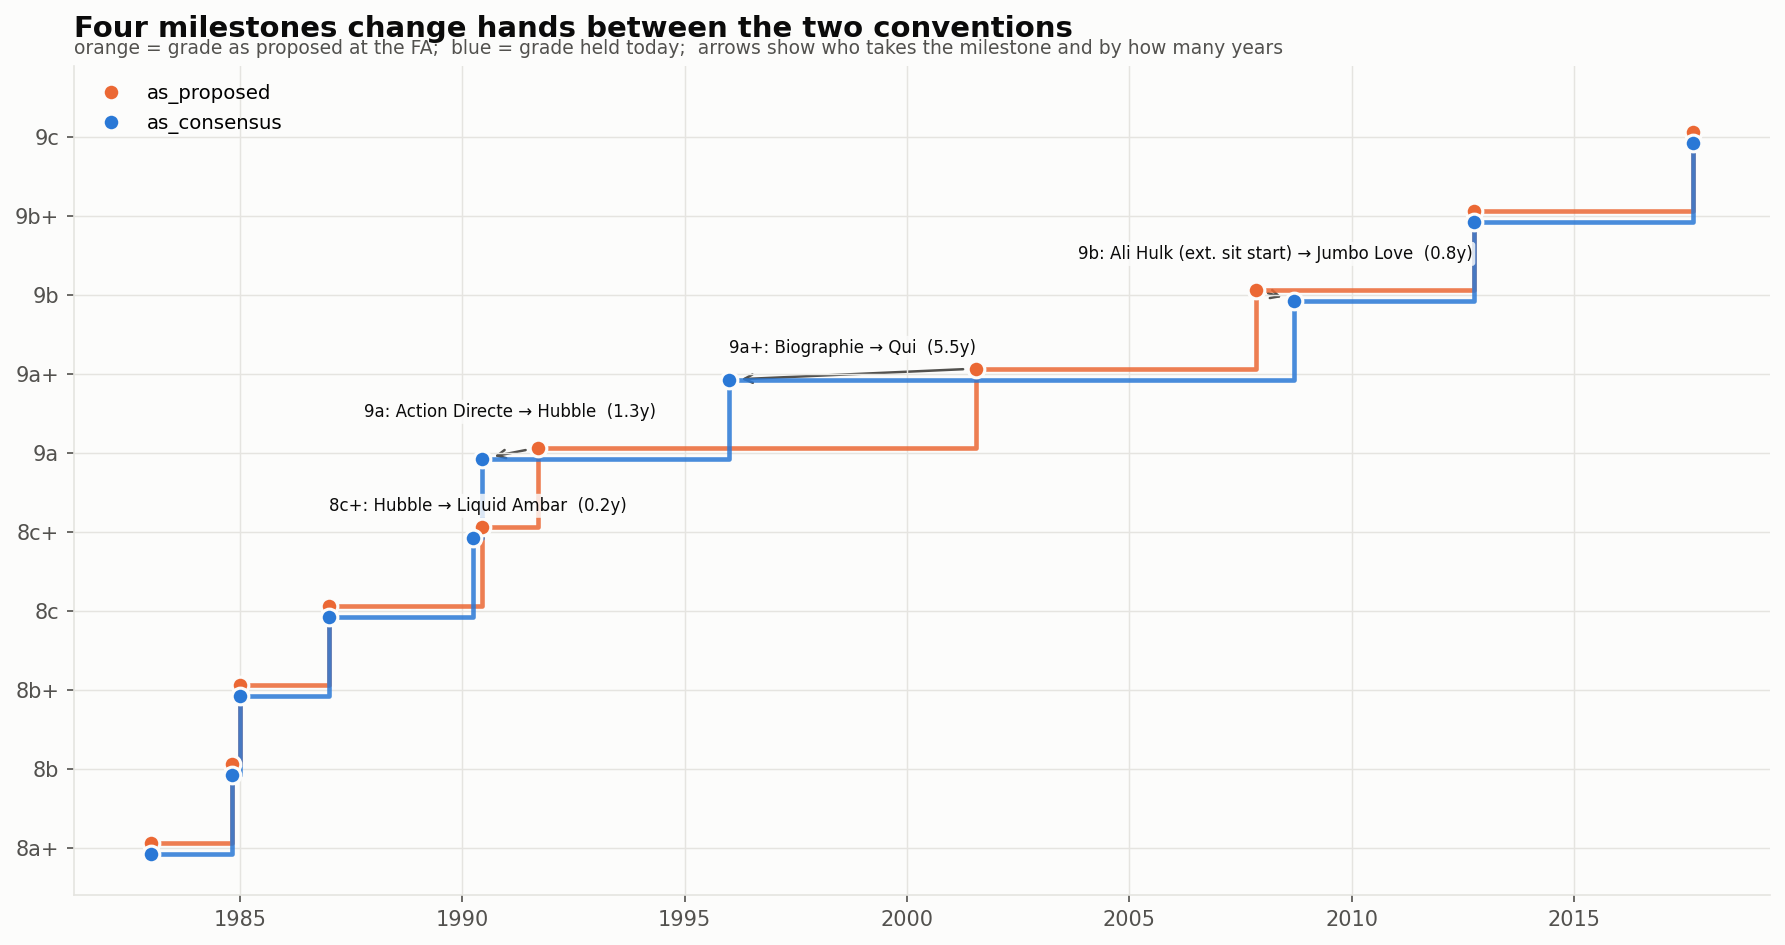

wrote timeline_conventions.png


In [6]:
# The two ladders on one axis: where the conventions diverge.
fig, ax = plt.subplots(figsize=(12, 6.4), dpi=150, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for (conv, t), color, dy in zip(tables.items(), (ORANGE, BLUE), (0.07, -0.07)):
    y = t["grade_order"] - BASE + dy
    ax.step(t["first_ascent"], y, where="post", color=color, lw=2.2,
            alpha=.85, zorder=2)
    ax.plot(t["first_ascent"], y, "o", ms=8, mfc=color, mec=SURFACE, mew=1.5,
            zorder=3, label=conv)

# Long route names cost more than they buy in a label that has to clear two
# step lines and an arrow.
SHORT = {"Ali Hulk (extension sit start)": "Ali Hulk (ext. sit start)"}
halo = dict(facecolor=SURFACE, edgecolor="none", alpha=.82,
            boxstyle="round,pad=0.18")

p = tables["as_proposed"].set_index("grade")
c = tables["as_consensus"].set_index("grade")
changed = [g for g in p.index if p.loc[g, "route"] != c.loc[g, "route"]]
for n, grade in enumerate(changed):
    a, b = p.loc[grade], c.loc[grade]
    y = a["grade_order"] - BASE
    ax.annotate("", xy=(b["first_ascent"], y - 0.07),
                xytext=(a["first_ascent"], y + 0.07),
                arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2,
                                shrinkA=6, shrinkB=6), zorder=1)
    gap = abs((a["first_ascent"] - b["first_ascent"]).days) / 365.25
    mid = a["first_ascent"] + (b["first_ascent"] - a["first_ascent"]) / 2
    label = (f"{grade}: {SHORT.get(a['route'], a['route'])} → "
             f"{SHORT.get(b['route'], b['route'])}  ({gap:.1f}y)")
    # Alternate the height so consecutive callouts cannot stack on each other,
    # and sit them on a halo so they stay readable over the step lines.
    ax.annotate(label, (mid, y + (0.46 if n % 2 else 0.27)), fontsize=8,
                color=INK, ha="center", zorder=5, bbox=halo)

ax.set_yticks(range(10)); ax.set_yticklabels(FRENCH_SCALE[BASE:BASE + 10])
ax.set_ylim(-0.6, 9.9)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(color=GRID, lw=.7, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.set_title("Four milestones change hands between the two conventions",
             color=INK, fontsize=14, loc="left", pad=14, fontweight="bold")
ax.text(0, 1.015, "orange = grade as proposed at the FA;  blue = grade held "
        "today;  arrows show who takes the milestone and by how many years",
        transform=ax.transAxes, fontsize=9, color=MUTED)
plt.tight_layout()
path = config.FIGURES_DIR / "timeline_conventions.png"
fig.savefig(path, facecolor=SURFACE, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"wrote {path.name}")